# Manual Neural Network (Multi-layer) – Grid Search over Learning Rate

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from functions import (
    cost, create_layers_batch, feed_forward_batch, feed_forward_saver_batch,
    backpropagation_batch, polynomial_features, plot_accuracy
)
from activations import (
    sigmoid, ReLU, leaky_ReLu, sigmoid_der, ReLU_der, leaky_ReLU_der, softmax, softmax_der
)
from costs import (
    mse, mse_der, cross_entropy, binary_cross_entropy_loss,
    binary_cross_entropy_loss_l1, binary_cross_entropy_loss_l2,
    multiclass_cross_entropy_loss, crossentropy_der, binary_cross_entropy_der
)
from train_funct import (
    train_network, train_network_SGD_momentum, train_network_RMSprop, train_network_ADAM
)

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
    roc_auc_score
)
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


## 1. Load the data

In [2]:
# Load dataset
df = pd.read_csv("../Data/heart.csv")  # adjust path if needed

# Separate target and features
target_col = "HeartDisease"
X = df.drop(columns=[target_col])
y = df[target_col].values.reshape(-1, 1)

## One-hot encoding of categorical variables

The following categorical features are one-hot encoded:
- Sex
- ChestPainType
- RestingECG
- ExerciseAngina
- ST_Slope


## 2. Data preparation

In [3]:
# One-hot encode categorical variables
categorical_cols = [
    "Sex",
    "ChestPainType",
    "RestingECG",
    "ExerciseAngina",
    "ST_Slope",
]

X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


## 3. Prepare data for the manual neural network

In [4]:
inputs_train = np.array(X_train)
targets_train = np.array(y_train)

inputs_test = np.array(X_test)
targets_test = np.array(y_test)

network_input_size = inputs_train.shape[1]
print("Network input size:", network_input_size)


Network input size: 15


## 4. Define the multi-layer NN 

In [5]:
# Multi-layer architecture
#layer_output_sizes = [64, 32, 1] # Used for RMSprop and ADAM
layer_output_sizes = [32, 16, 1]

activation_funcs = [ReLU, ReLU, sigmoid]
activation_ders  = [ReLU_der, ReLU_der, sigmoid_der]

# Training settings
learning_rates = [1e-4, 1e-3, 1e-2, 1e-1]
epochs = 400


## 5. Helper: confusion matrix plot

In [6]:
def plot_confusion_matrix(cm, title="", class_names=("No CVD", "CVD"), cmap="set3"):
    fig, ax = plt.subplots(figsize=(4, 4))
    im = ax.imshow(cm, cmap=cmap)

    ax.set_xticks(np.arange(len(class_names)))
    ax.set_yticks(np.arange(len(class_names)))
    ax.set_xticklabels(class_names)
    ax.set_yticklabels(class_names)

    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)

    # Annotate cells
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=12)

    plt.tight_layout()
    plt.show()


## 6. Grid search over learning rate

In [7]:
def grid_search_lr_for_trainer(trainer_func, trainer_name, learning_rates, epochs=300, **trainer_extra_kwargs):
    """Learning-rate grid search for a given trainer.

    For each LR:
      - Train the model from a fresh random init
      - Compute train/test accuracy
    Then:
      - Plot train/test accuracy vs LR (log scale)
      - Retrain with the best LR (by test accuracy)
      - Print confusion matrix + Accuracy/Precision/Recall/F1
      - Plot confusion matrix
      - Plot ROC curve + AUC

    Returns:
      results_df, best_bundle
    """
    results = []
    best_lr = None
    best_test_acc = -np.inf

    for lr in learning_rates:
        layers_init = create_layers_batch(network_input_size, layer_output_sizes)

        preds_hist, last_pred, layers_trained = trainer_func(
            inputs_train,
            layers_init,
            activation_funcs,
            targets_train,
            activation_ders,
            learning_rate=lr,
            epochs=epochs,
            cost_der=binary_cross_entropy_der,
            **trainer_extra_kwargs,
        )

        # Train accuracy
        train_preds = (last_pred >= 0.5).astype(int)
        train_acc = accuracy_score(targets_train, train_preds)

        # Test accuracy
        test_probs = feed_forward_batch(inputs_test, layers_trained, activation_funcs)
        test_preds = (test_probs >= 0.5).astype(int)
        test_acc = accuracy_score(targets_test, test_preds)

        results.append((lr, train_acc, test_acc))
        print(f"[{trainer_name}] lr={lr:.1e} -> train_acc={train_acc:.3f}, test_acc={test_acc:.3f}")

        if test_acc > best_test_acc:
            best_test_acc = test_acc
            best_lr = lr

    # ---- Plot: train vs test accuracy vs LR ----
    lrs = np.array([r[0] for r in results])
    train_accs = np.array([r[1] for r in results])
    test_accs  = np.array([r[2] for r in results])

    plt.figure(figsize=(8, 4))
    plt.xscale("log")
    plt.plot(lrs, train_accs, marker="o", label="Train Accuracy")
    plt.plot(lrs, test_accs,  marker="s", label="Test Accuracy")
    plt.xlabel("Learning rate (log scale)")
    plt.ylabel("Accuracy")
    plt.title(f"Learning Rate Grid Search – {trainer_name}")
    plt.grid(True, which="both", linestyle="--", alpha=0.4)
    plt.legend()
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()

    print(f"\nBest LR for {trainer_name} by test accuracy: {best_lr:.1e} (test_acc = {best_test_acc:.3f})")

    # ============================================================
    # Retrain with best_lr, then compute metrics + ROC
    # ============================================================
    layers_init = create_layers_batch(network_input_size, layer_output_sizes)

    preds_hist_best, last_pred_best, layers_trained_best = trainer_func(
        inputs_train,
        layers_init,
        activation_funcs,
        targets_train,
        activation_ders,
        learning_rate=best_lr,
        epochs=epochs,
        cost_der=binary_cross_entropy_der,
        **trainer_extra_kwargs,
    )

    test_probs_best = feed_forward_batch(inputs_test, layers_trained_best, activation_funcs)
    y_true = targets_test.ravel()
    y_score = test_probs_best.ravel()
    y_pred = (y_score >= 0.5).astype(int)

    cm = confusion_matrix(y_true, y_pred)

    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    auc  = roc_auc_score(y_true, y_score)

    print("\n=== Test metrics for best LR ===")
    print(f"Optimizer: {trainer_name}")
    print(f"Best LR   : {best_lr:.1e}")
    print("Confusion matrix [ [TN FP]\n                 [FN TP] ]:")
    print(cm)
    plot_confusion_matrix(cm, title=f"Confusion Matrix – {trainer_name} (lr={best_lr:.1e})", cmap="tab20")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(f"AUC      : {auc:.4f}")
    print("\nClassification report (test):")
    print(classification_report(y_true, y_pred))

    # ---- ROC curve ----
    fpr, tpr, _ = roc_curve(y_true, y_score)
    plt.figure(figsize=(6, 6))
    plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc:.3f})")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
    plt.xlabel("False Positive Rate", fontsize=16)
    plt.ylabel("True Positive Rate", fontsize=16)
    plt.title(f"ROC Curve – {trainer_name} (best lr = {best_lr:.1e})")
    plt.legend(loc="lower right", fontsize=12, frameon=True)
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()


    results_df = pd.DataFrame(results, columns=["learning_rate", "train_accuracy", "test_accuracy"])
    best_bundle = {
        "optimizer": trainer_name,
        "best_lr": best_lr,
        "best_test_acc": best_test_acc,
        "acc": acc, "prec": prec, "rec": rec, "f1": f1, "auc": auc,
    }
    return results_df, best_bundle


## 7. Run grid search for each gradient method

[GD] lr=1.0e-04 -> train_acc=0.495, test_acc=0.486
[GD] lr=1.0e-03 -> train_acc=0.495, test_acc=0.486
[GD] lr=1.0e-02 -> train_acc=0.497, test_acc=0.489
[GD] lr=1.0e-01 -> train_acc=0.526, test_acc=0.522


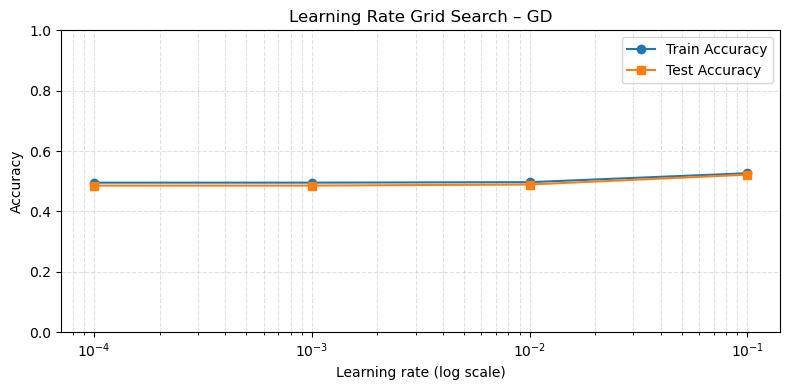


Best LR for GD by test accuracy: 1.0e-01 (test_acc = 0.522)

=== Test metrics for best LR ===
Optimizer: GD
Best LR   : 1.0e-01
Confusion matrix [ [TN FP]
                 [FN TP] ]:
[[ 34  89]
 [ 43 110]]


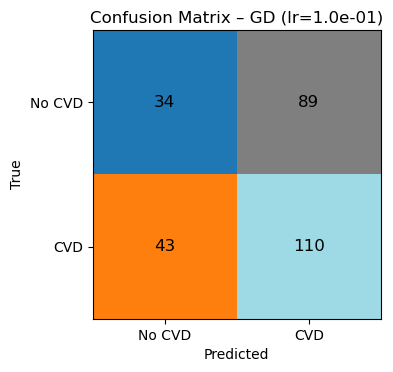

Accuracy : 0.5217
Precision: 0.5528
Recall   : 0.7190
F1-score : 0.6250
AUC      : 0.5131

Classification report (test):
              precision    recall  f1-score   support

           0       0.44      0.28      0.34       123
           1       0.55      0.72      0.62       153

    accuracy                           0.52       276
   macro avg       0.50      0.50      0.48       276
weighted avg       0.50      0.52      0.50       276



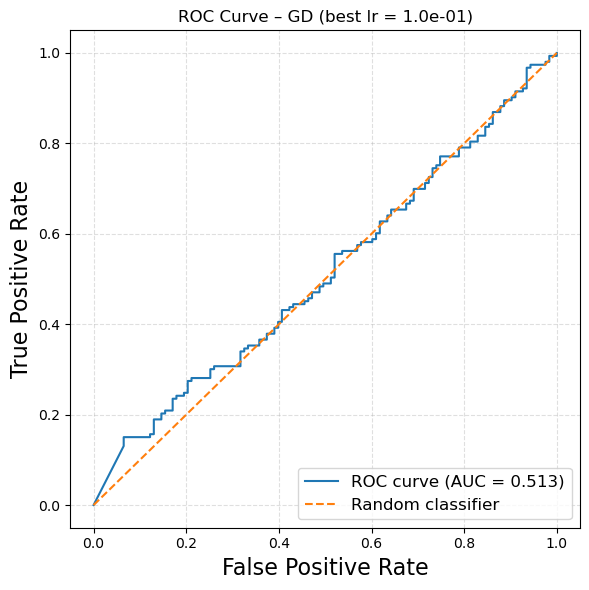

[SGD + Momentum] lr=1.0e-04 -> train_acc=0.495, test_acc=0.486
[SGD + Momentum] lr=1.0e-03 -> train_acc=0.497, test_acc=0.489
[SGD + Momentum] lr=1.0e-02 -> train_acc=0.509, test_acc=0.496
[SGD + Momentum] lr=1.0e-01 -> train_acc=0.682, test_acc=0.670


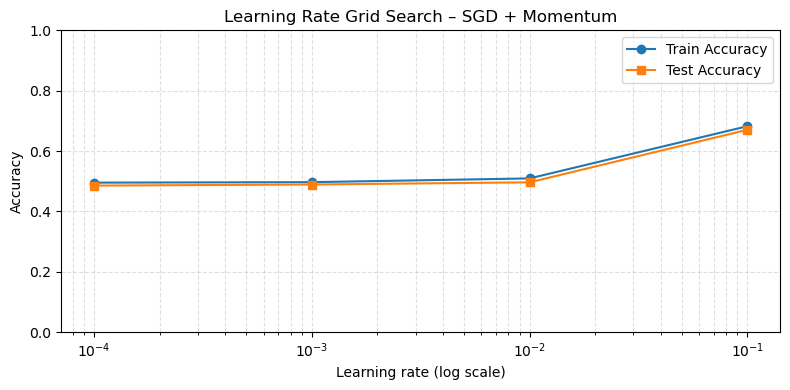


Best LR for SGD + Momentum by test accuracy: 1.0e-01 (test_acc = 0.670)

=== Test metrics for best LR ===
Optimizer: SGD + Momentum
Best LR   : 1.0e-01
Confusion matrix [ [TN FP]
                 [FN TP] ]:
[[ 72  51]
 [ 40 113]]


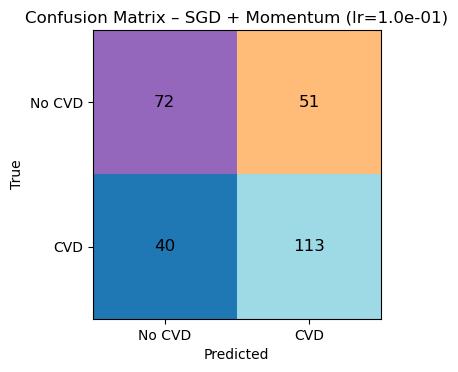

Accuracy : 0.6703
Precision: 0.6890
Recall   : 0.7386
F1-score : 0.7129
AUC      : 0.6861

Classification report (test):
              precision    recall  f1-score   support

           0       0.64      0.59      0.61       123
           1       0.69      0.74      0.71       153

    accuracy                           0.67       276
   macro avg       0.67      0.66      0.66       276
weighted avg       0.67      0.67      0.67       276



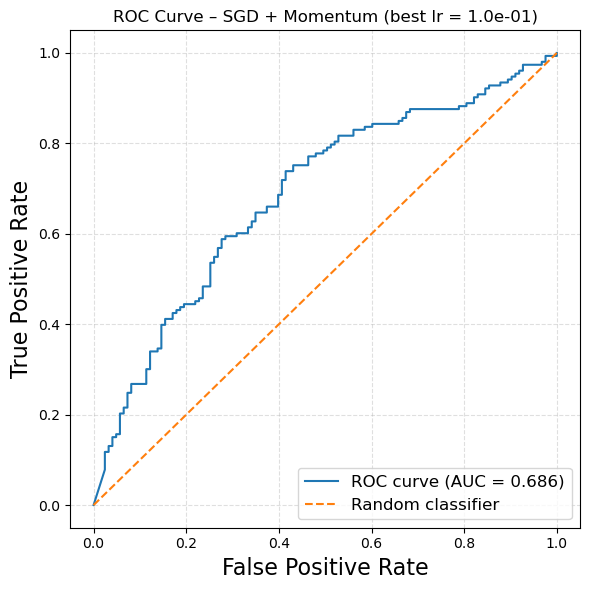

[RMSprop] lr=1.0e-04 -> train_acc=0.531, test_acc=0.500
[RMSprop] lr=1.0e-03 -> train_acc=0.925, test_acc=0.841
[RMSprop] lr=1.0e-02 -> train_acc=0.960, test_acc=0.866


/Users/natalliadanilchanka/anaconda3/lib/python3.11/site-packages/autograd/tracer.py:48: RuntimeWarning: overflow encountered in exp
  return f_raw(*args, **kwargs)


[RMSprop] lr=1.0e-01 -> train_acc=0.883, test_acc=0.888


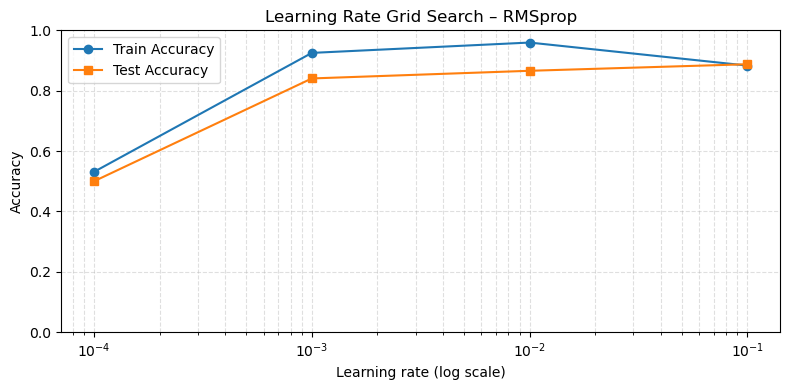


Best LR for RMSprop by test accuracy: 1.0e-01 (test_acc = 0.888)

=== Test metrics for best LR ===
Optimizer: RMSprop
Best LR   : 1.0e-01
Confusion matrix [ [TN FP]
                 [FN TP] ]:
[[ 98  25]
 [  6 147]]


/Users/natalliadanilchanka/anaconda3/lib/python3.11/site-packages/autograd/tracer.py:48: RuntimeWarning: overflow encountered in exp
  return f_raw(*args, **kwargs)


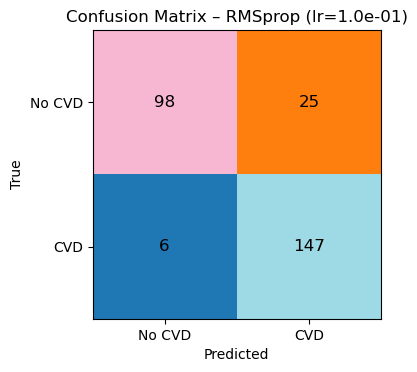

Accuracy : 0.8877
Precision: 0.8547
Recall   : 0.9608
F1-score : 0.9046
AUC      : 0.8862

Classification report (test):
              precision    recall  f1-score   support

           0       0.94      0.80      0.86       123
           1       0.85      0.96      0.90       153

    accuracy                           0.89       276
   macro avg       0.90      0.88      0.88       276
weighted avg       0.89      0.89      0.89       276



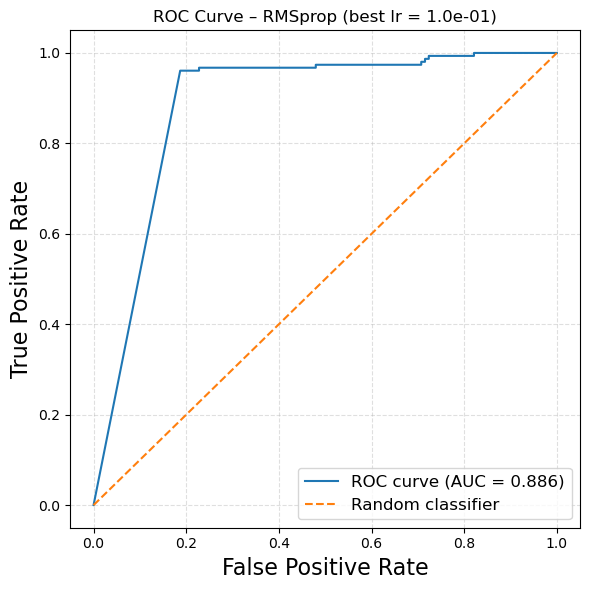

[Adam] lr=1.0e-04 -> train_acc=0.537, test_acc=0.500
[Adam] lr=1.0e-03 -> train_acc=0.886, test_acc=0.848
[Adam] lr=1.0e-02 -> train_acc=0.924, test_acc=0.873
[Adam] lr=1.0e-01 -> train_acc=0.877, test_acc=0.888


/Users/natalliadanilchanka/anaconda3/lib/python3.11/site-packages/autograd/tracer.py:48: RuntimeWarning: overflow encountered in exp
  return f_raw(*args, **kwargs)
/Users/natalliadanilchanka/anaconda3/lib/python3.11/site-packages/autograd/tracer.py:48: RuntimeWarning: overflow encountered in exp
  return f_raw(*args, **kwargs)


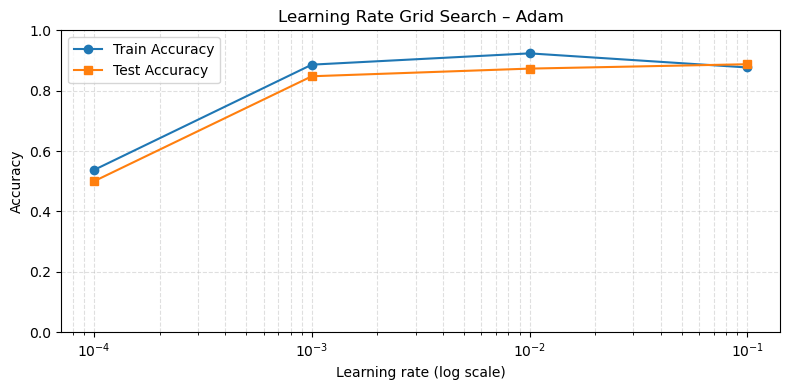


Best LR for Adam by test accuracy: 1.0e-01 (test_acc = 0.888)

=== Test metrics for best LR ===
Optimizer: Adam
Best LR   : 1.0e-01
Confusion matrix [ [TN FP]
                 [FN TP] ]:
[[104  19]
 [ 12 141]]


/Users/natalliadanilchanka/anaconda3/lib/python3.11/site-packages/autograd/tracer.py:48: RuntimeWarning: overflow encountered in exp
  return f_raw(*args, **kwargs)


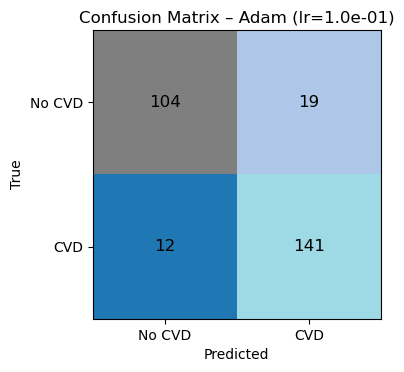

Accuracy : 0.8877
Precision: 0.8812
Recall   : 0.9216
F1-score : 0.9010
AUC      : 0.8984

Classification report (test):
              precision    recall  f1-score   support

           0       0.90      0.85      0.87       123
           1       0.88      0.92      0.90       153

    accuracy                           0.89       276
   macro avg       0.89      0.88      0.89       276
weighted avg       0.89      0.89      0.89       276



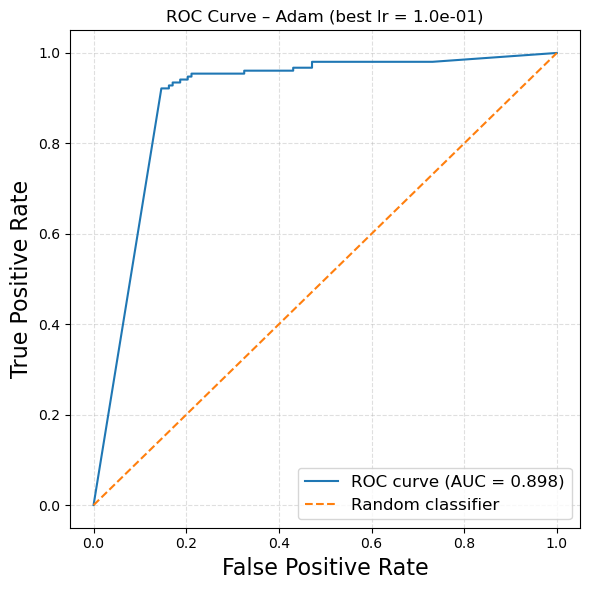

,optimizer,best_lr,best_test_acc,acc,prec,rec,f1,auc
0,GD,0.1,0.521739,0.521739,0.552764,0.718954,0.625000,0.513098
1,SGD + Momentum,0.1,0.670290,0.670290,0.689024,0.738562,0.712934,0.686062
2,RMSprop,0.1,0.887681,0.887681,0.854651,0.960784,0.904615,0.886152
3,Adam,0.1,0.887681,0.887681,0.881250,0.921569,0.900958,0.898374


In [8]:
all_summaries = []

# 1) Plain Gradient Descent (GD)
df_gd, best_gd = grid_search_lr_for_trainer(
    trainer_func=train_network,
    trainer_name="GD",
    learning_rates=learning_rates,
    epochs=epochs,
)
all_summaries.append(best_gd)

# 2) SGD + Momentum
df_sgd, best_sgd = grid_search_lr_for_trainer(
    trainer_func=train_network_SGD_momentum,
    trainer_name="SGD + Momentum",
    learning_rates=learning_rates,
    epochs=epochs,
    momentum=0.8,
)
all_summaries.append(best_sgd)

# for more advanced method set NN with mode nodes
layer_output_sizes = [64, 32, 1]


# 3) RMSprop
df_rms, best_rms = grid_search_lr_for_trainer(
    trainer_func=train_network_RMSprop,
    trainer_name="RMSprop",
    learning_rates=learning_rates,
    epochs=epochs,
    rho=0.9,
    eps=1e-8,
    grad_tol=1e-8,
    verbose=False,
)
all_summaries.append(best_rms)

# 4) Adam
df_adam, best_adam = grid_search_lr_for_trainer(
    trainer_func=train_network_ADAM,
    trainer_name="Adam",
    learning_rates=learning_rates,
    epochs=epochs,
    beta1=0.9,
    beta2=0.999,
    eps=1e-8,
    grad_tol=1e-8,
    verbose=False,
)
all_summaries.append(best_adam)

summary_df = pd.DataFrame(all_summaries)
summary_df
